In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.tree import (DecisionTreeClassifier, plot_tree)

from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report)

In [2]:
df = pd.read_csv(
    "/content/bank-additional-full.csv",
    sep=';'
)

In [3]:
print(df.head())
print(df.shape)
print(df.info())
print(df.columns)

   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed

In [4]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


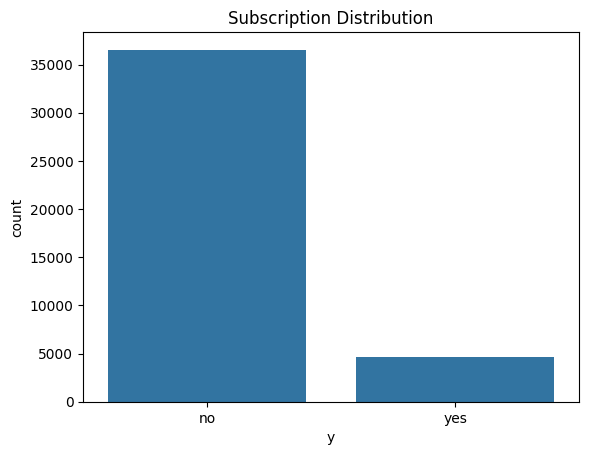

In [5]:
sns.countplot(
    x='y',
    data=df
)

plt.title("Subscription Distribution")

plt.show()

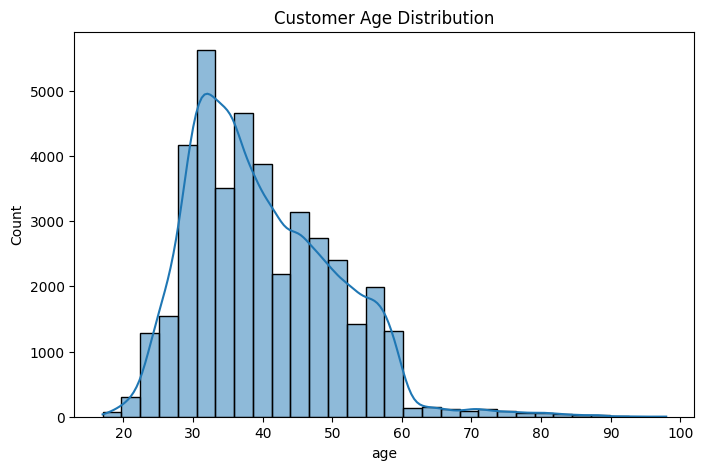

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['age'],
    bins=30,
    kde=True
)

plt.title("Customer Age Distribution")

plt.show()

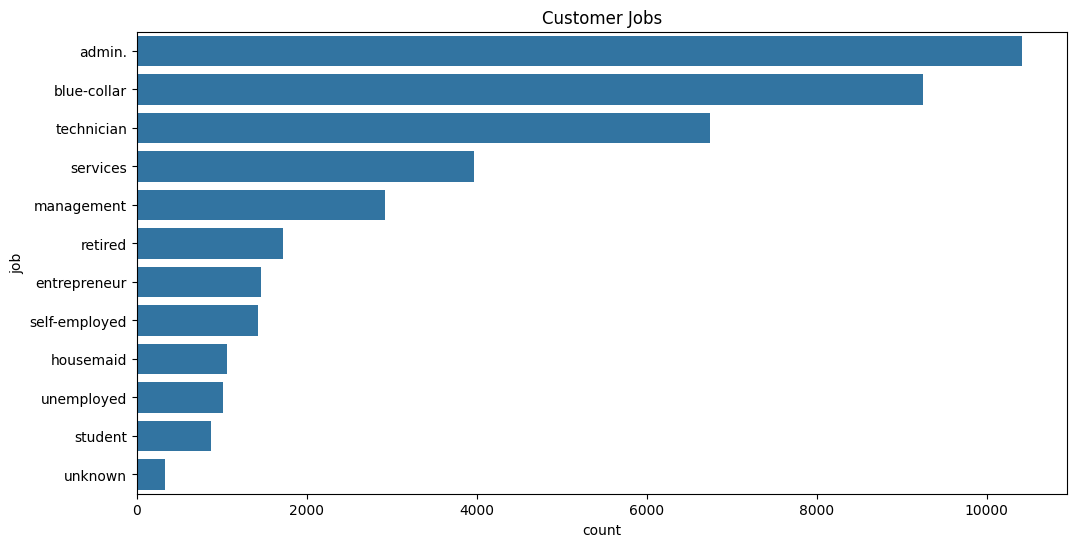

In [7]:
plt.figure(figsize=(12,6))

sns.countplot(
    y='job',
    data=df,
    order=df['job'].value_counts().index
)

plt.title("Customer Jobs")

plt.show()

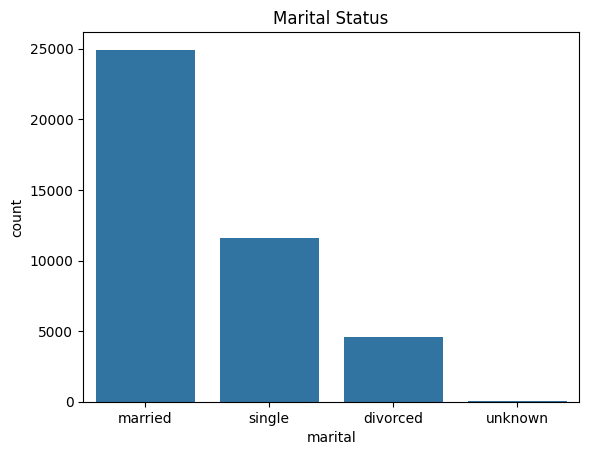

In [8]:
sns.countplot(
    x='marital',
    data=df
)

plt.title("Marital Status")

plt.show()

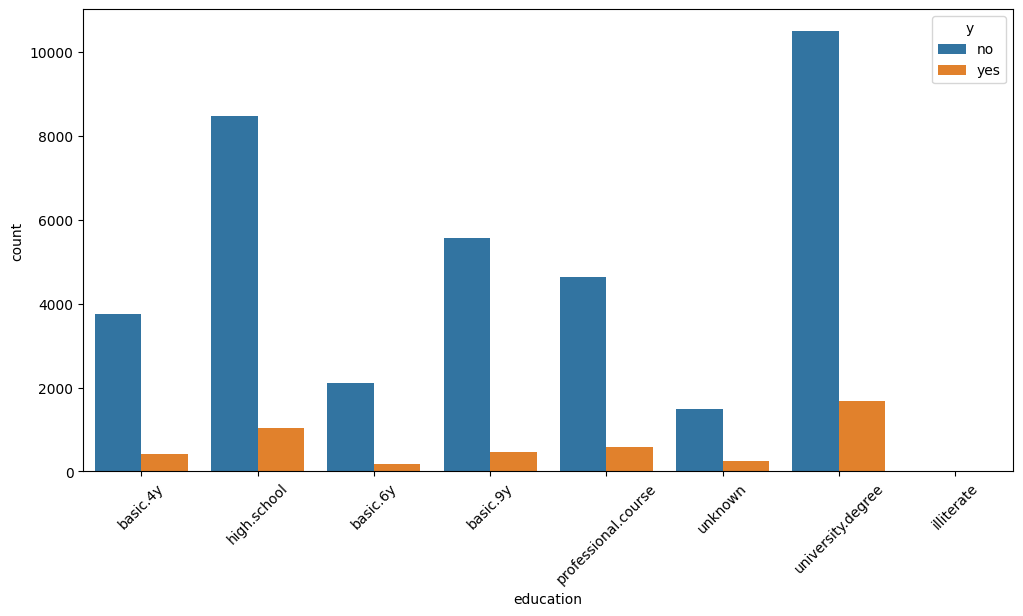

In [9]:
plt.figure(figsize=(12,6))

sns.countplot(
    x='education',
    hue='y',
    data=df
)

plt.xticks(rotation=45)

plt.show()

In [10]:
df['y'] = df['y'].map({
    'yes':1,
    'no':0
})

In [11]:
cat_cols = df.select_dtypes(
    include='object'
).columns

In [12]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [13]:
X = df.drop(
    'y',
    axis=1
)

y = df['y']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt.fit(
    X_train,
    y_train
)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [16]:
y_pred = dt.predict(X_test)

In [17]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy:",
    accuracy
)

Accuracy: 0.9149065307113377


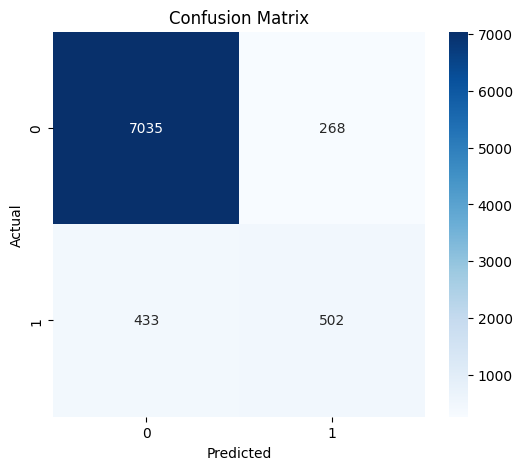

In [18]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [19]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.94      0.96      0.95      7303
           1       0.65      0.54      0.59       935

    accuracy                           0.91      8238
   macro avg       0.80      0.75      0.77      8238
weighted avg       0.91      0.91      0.91      8238



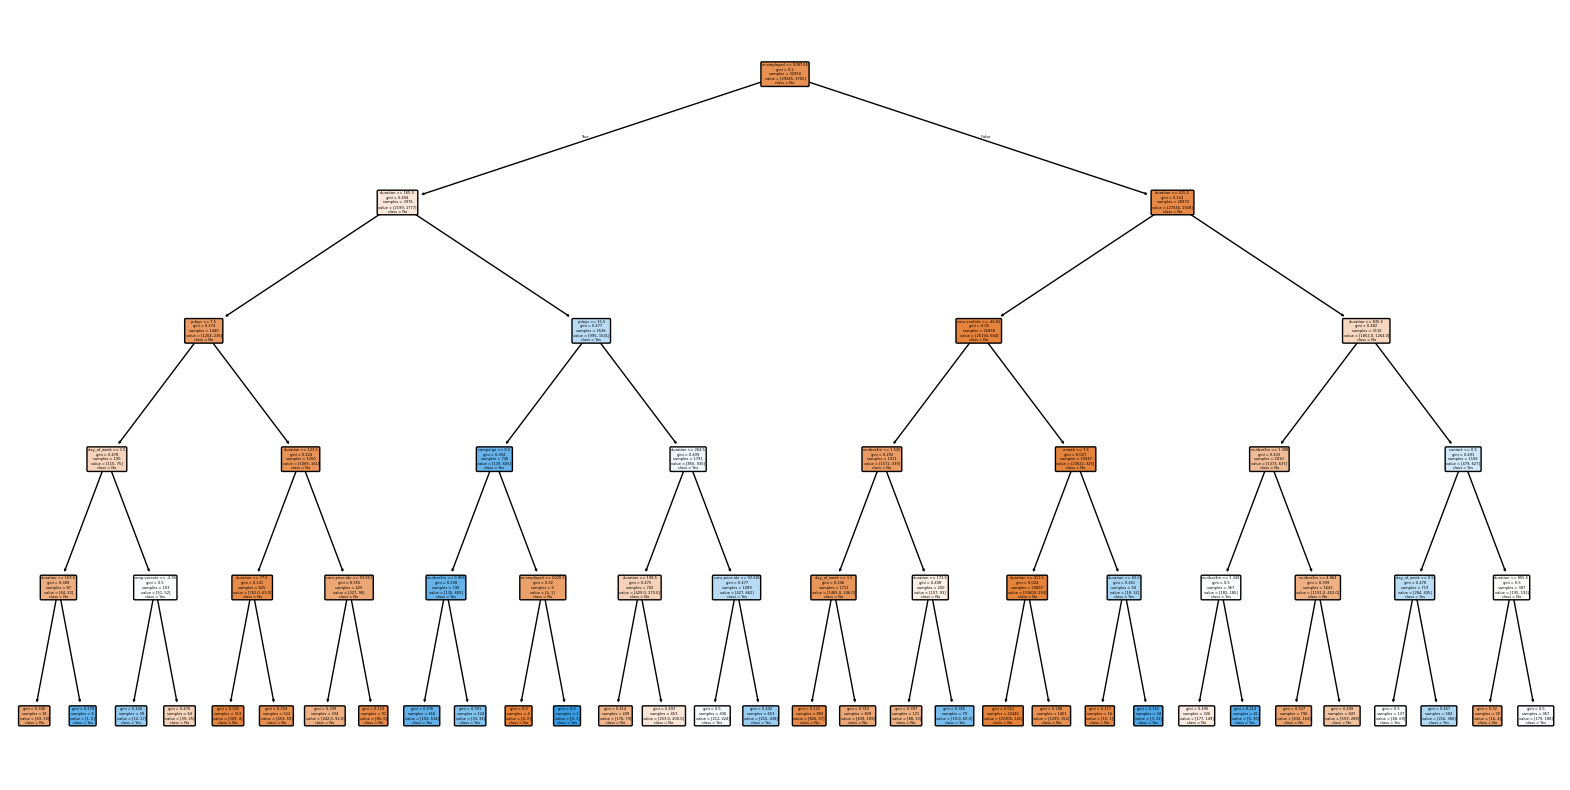

In [20]:
plt.figure(
    figsize=(20,10)
)

plot_tree(
    dt,
    feature_names=X.columns,
    class_names=['No','Yes'],
    filled=True,
    rounded=True
)

plt.show()

In [21]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

In [22]:
print(
    importance.head(10)
)

           Feature  Importance
10        duration    0.494374
19     nr.employed    0.359908
12           pdays    0.040013
18       euribor3m    0.034857
17   cons.conf.idx    0.033738
8            month    0.013966
9      day_of_week    0.011307
16  cons.price.idx    0.006807
7          contact    0.002119
15    emp.var.rate    0.001567


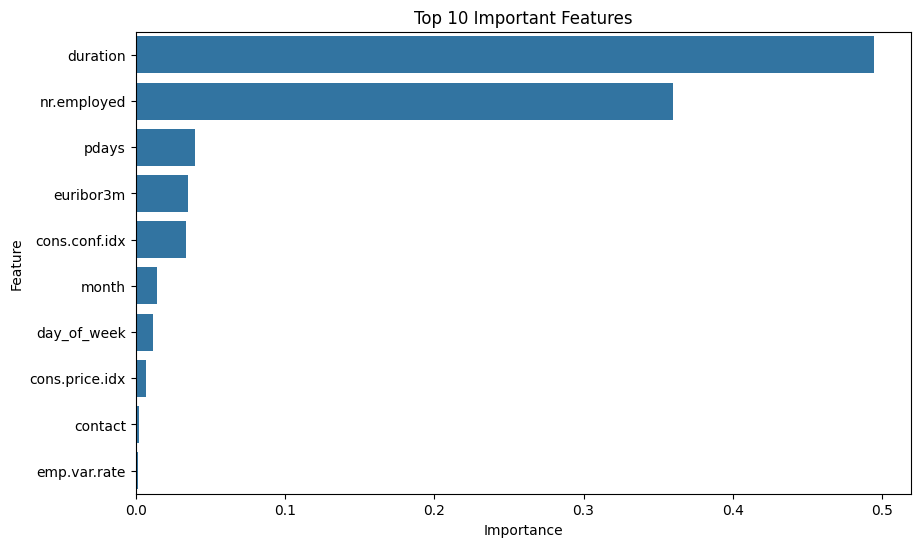

In [23]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title(
    "Top 10 Important Features"
)

plt.show()